# Classificatore Real+Augmented (`trad_aug`) - ResNet-50

Classificatore addestrato su dati arrichiti tramite augmentation tradizionale.
Viene utilizzato il modello **ResNet-50** utilizzato nelle altre configurazioni e riaddestrato sui dati arricchiti.

- **train-set** = immagini originali reali a 2 classi (`data/processed/train/{0,1}`) **+** positivi augmentati
  in modo tradizionale (`data/real_augmented/`, solo casi positivi).
- **val/test-set** = solo immagini reali (`data/processed/`)

#### Setup percorsi

In [ ]:
import os, sys
from pathlib import Path

#rileva Colab oppure ambiente locale/WSL e imposta il percorso di MammoDiffusion
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
else:
    print("ambiente locale/WSL")
    BASE_PATH = None
    for _cand in [Path.cwd(), *Path.cwd().parents]:
        if (_cand / 'data' / 'processed').is_dir():
            BASE_PATH = str(_cand) + os.sep
            break
    if BASE_PATH is None:
        BASE_PATH = '/mnt/c/Users/samto/Desktop/MammoDiffusion/' #path personale
print("percorso base:", BASE_PATH)

Ambiente locale/WSL rilevato.
Percorso base: /mnt/c/Users/samto/Desktop/MammoDiffusion/


#### Import

In [ ]:
import re
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             classification_report, precision_score,
                             recall_score, f1_score, accuracy_score)

#### Ottimizzazione per addestramento su GPU

In [ ]:
#memory growth per GPU altrimenti TF pre-alloca tutta la memoria
gpus = tf.config.list_physical_devices('GPU')
print("GPU viste da TF:", gpus)
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("set_memory_growth:", e)
if not gpus:
    print("nessuna GPU vista da TF - utilizzo CPU")

#mixed precision per dimezzare la VRAM. Se la attivi, tieni l'ultimo layer in float32
#from tensorflow.keras import mixed_precision
#(Dense(1, activation='sigmoid', dtype='float32'))
#mixed_precision.set_global_policy('mixed_float16')

GPU viste da TF: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#### Configurazione

In [ ]:
SEED = 42
ARCH = "ResNet-50" 
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
UNFREEZE_FROM = "conv4_block5_1_conv"   #layer da cui sbloccare la backbone in Fase 2
BACKBONE_NAME = "resnet50"              #nome del layer backbone per eventuale Grad-CAM
CONFIG = "trad_aug"                     #nome configurazione

IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225])
AUTOTUNE = tf.data.AUTOTUNE

AUG_ONLINE = False      #l'augmentation è già presente nella cartella data/real_augmented

OUTPUT_DIR = os.path.join(BASE_PATH, 'experiments', 'exp_trad_aug_resnet50')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

keras.utils.set_random_seed(SEED)
print("ARCH:", ARCH, "| IMG_SIZE:", IMG_SIZE, "| BATCH:", BATCH_SIZE, "| OUTPUT_DIR:", OUTPUT_DIR)

ARCH: ResNet-50 | IMG_SIZE: (224, 224) | BATCH: 4 | OUTPUT_DIR: /mnt/c/Users/samto/Desktop/MammoDiffusion/experiments/exp_trad_aug_resnet50


I0000 00:00:1781714415.383500    1504 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1751 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


#### Costruzione subset per l'addestramento

In [ ]:
DIR_TRAIN = os.path.join(BASE_PATH, 'data', 'processed', 'train')   #sottocartelle 0 (sano) e 1 (malato)
DIR_VAL   = os.path.join(BASE_PATH, 'data', 'processed', 'val')
DIR_TEST  = os.path.join(BASE_PATH, 'data', 'processed', 'test')
DIR_AUG   = os.path.join(BASE_PATH, 'data', 'real_augmented')       #immagini augmentate con i soli casi positivi

_LABEL_RE = re.compile(r"_label([01])")

#immagini originali - la label è nel nome della sottocartella (0=sano / 1=malato)
def carica_da_cartelle_classi(base_dir, classi=("0", "1")):
    paths, labels = [], []
    for c in classi:
        for p in sorted(Path(base_dir).joinpath(c).glob("*.png")):
            paths.append(str(p)); labels.append(int(c))
    return np.array(paths), np.array(labels, dtype=np.int32)

#immagini augmentate - la label è nel nome del file (label0 / label1)
def carica_da_nome(dirpath):
    paths, labels = [], []
    for p in sorted(Path(dirpath).glob("*.png")):
        m = _LABEL_RE.search(p.name)
        if m is None:
            continue
        paths.append(str(p)); labels.append(int(m.group(1)))
    return np.array(paths), np.array(labels, dtype=np.int32)

#train set contiene dati reali (2 classi) + augmentati positivi
#validation e test set contengono solo reali 
real_tr_p, real_tr_y = carica_da_cartelle_classi(DIR_TRAIN)
aug_p, aug_y = carica_da_nome(DIR_AUG)
train_p = np.concatenate([real_tr_p, aug_p])
train_y = np.concatenate([real_tr_y, aug_y])
val_p, val_y = carica_da_cartelle_classi(DIR_VAL)
test_p, test_y = carica_da_cartelle_classi(DIR_TEST)

def _comp(nome, y):
    print("%-6s tot=%5d | sano(0)=%5d | malato(1)=%5d" % (nome, len(y), int((y==0).sum()), int((y==1).sum())))
print("[trad_aug] reali train=%d + augmentati positivi=%d" % (len(real_tr_y), len(aug_y)))
_comp("TRAIN", train_y); _comp("VAL", val_y); _comp("TEST", test_y)

def _preprocess(path, label, augment):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    if augment:
        img = img + tf.random.normal(tf.shape(img), mean=0.0, stddev=0.05)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    return img, tf.cast(label, tf.float32)

def make_ds(p, y, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((p, y))
    if shuffle:
        ds = ds.shuffle(len(p), seed=SEED)
    ds = ds.map(lambda a, b: _preprocess(a, b, augment), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(train_p, train_y, augment=AUG_ONLINE, shuffle=True)
val_ds   = make_ds(val_p, val_y, augment=False, shuffle=False)
test_ds  = make_ds(test_p, test_y, augment=False, shuffle=False)

#pesi delle classi dal train trad_aug, poichè anche con gli augmentati i positivi restano meno numerosi
_classes = np.unique(train_y)
_w = compute_class_weight("balanced", classes=_classes, y=train_y)
class_weight_dict = dict(zip(_classes.astype(int), _w))
print("class weights:", class_weight_dict)

[trad_aug] reali train=2041 + augmentati positivi=1020
TRAIN  tot= 3061 | Sano(0)= 1701 | Malato(1)= 1360
VAL    tot=  437 | Sano(0)=  364 | Malato(1)=   73
TEST   tot=  438 | Sano(0)=  365 | Malato(1)=   73
Class weights: {np.int64(0): np.float64(0.8997648442092887), np.int64(1): np.float64(1.1253676470588236)}


#### Architettura ResNet-50

Backbone utilizzata per le altre configurazioni viene riaddestrata

In [ ]:
def build_model():
    base_model = keras.applications.ResNet50(
        weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,)
    )
    base_model.trainable = False   #fase 1 - backbone congelato
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = base_model(inputs, training=False)   #training=False per la BatchNorm del backbone
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs), base_model

model, base_model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,537 (91.99 MB)

 Trainable params: 525,313 (2.00 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

#### Training in 2 fasi

In [ ]:
#fase 1 - addestra solo la head, si utilizza binary crossentropy
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Recall(name='recall')]
)
cb1 = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=7, restore_best_weights=True, mode='max'),
    keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, 'trad_aug_resnet50_fase1_best.keras'), monitor='val_auc', save_best_only=True, mode='max'),
]

history_phase1 = model.fit(train_ds, epochs=25, validation_data=val_ds, class_weight=class_weight_dict, callbacks=cb1)

#fase 2 - fine-tuning dal layer UNFREEZE_FROM in poi
base_model.trainable = True
fine_tune_at = "conv4_block5_1_conv"        #si utilizza il medesimo punto di sblocco delle altre configurazioni
set_trainable = False

for layer in base_model.layers:
    if layer.name == 'conv4_block5_1_conv':  #circa 31% di layer sbloccati come in EfficientNetB3
        set_trainable = True
    layer.trainable = set_trainable

#esegue il freeze dei BatchNorm
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

#stampa per verifica
print(f"totale layer nel base_model: {len(base_model.layers)}")
trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
print(f"layer resi addestrabili per il fine-tuning: {trainable_count}")
  
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.BinaryFocalCrossentropy(
        apply_class_balancing=True,
        alpha=0.75,
        gamma=2.0,
        from_logits=False
    ),
    metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Recall(name='recall')]
)
cb2 = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, min_delta=1e-3, restore_best_weights=True, mode='max'),
    keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, 'trad_aug_resnet50_final_best.keras'), monitor='val_auc', save_best_only=True, mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, mode='max', min_lr=1e-7),
]
history_phase2 = model.fit(train_ds, epochs=30, validation_data=val_ds, callbacks=cb2)

[codecarbon WARNING @ 18:40:39] Multiple instances of codecarbon are allowed to run at the same time.


Epoch 1/25


2026-06-17 18:40:56.431598: I external/local_xla/xla/service/service.cc:163] XLA service 0x727b58004150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-17 18:40:56.431778: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2026-06-17 18:40:57.091418: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-17 18:41:00.850340: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92302


  1/766 ━━━━━━━━━━━━━━━━━━━━ 4:41:59 22s/step - accuracy: 0.5000 - auc: 0.5000 - loss: 1.1923 - recall: 0.5000

I0000 00:00:1781714468.981854    1736 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


766/766 ━━━━━━━━━━━━━━━━━━━━ 71s 63ms/step - accuracy: 0.5472 - auc: 0.5561 - loss: 0.8328 - recall: 0.5346 - val_accuracy: 0.3089 - val_auc: 0.6300 - val_loss: 1.1250 - val_recall: 0.9178
Epoch 2/25
766/766 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.5841 - auc: 0.6168 - loss: 0.7374 - recall: 0.6029 - val_accuracy: 0.7895 - val_auc: 0.6130 - val_loss: 0.5346 - val_recall: 0.1370
Epoch 3/25
766/766 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.6024 - auc: 0.6421 - loss: 0.7137 - recall: 0.6110 - val_accuracy: 0.7391 - val_auc: 0.5959 - val_loss: 0.5786 - val_recall: 0.2329
Epoch 4/25
766/766 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.5913 - auc: 0.6334 - loss: 0.7143 - recall: 0.5728 - val_accuracy: 0.6087 - val_auc: 0.5918 - val_loss: 0.6927 - val_recall: 0.5205
Epoch 5/25
766/766 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step - accuracy: 0.6093 - auc: 0.6509 - loss: 0.7033 - recall: 0.6235 - val_accuracy: 0.4279 - val_auc: 0.6339 - val_loss: 0.8565 - val_recall: 0.8356
Epoch 6/25


2026-06-17 18:47:40.285346: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.27GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-06-17 18:47:40.558533: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.27GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


766/766 ━━━━━━━━━━━━━━━━━━━━ 125s 117ms/step - accuracy: 0.6090 - auc: 0.6640 - loss: 0.2088 - recall: 0.6478 - val_accuracy: 0.6705 - val_auc: 0.6494 - val_loss: 0.1979 - val_recall: 0.5205 - learning_rate: 1.0000e-05
Epoch 2/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 57s 74ms/step - accuracy: 0.7011 - auc: 0.7848 - loss: 0.1632 - recall: 0.7294 - val_accuracy: 0.7048 - val_auc: 0.6423 - val_loss: 0.1822 - val_recall: 0.4384 - learning_rate: 1.0000e-05
Epoch 3/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 58s 76ms/step - accuracy: 0.7645 - auc: 0.8425 - loss: 0.1453 - recall: 0.7801 - val_accuracy: 0.6751 - val_auc: 0.6001 - val_loss: 0.2032 - val_recall: 0.3836 - learning_rate: 1.0000e-05
Epoch 4/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 58s 76ms/step - accuracy: 0.8004 - auc: 0.8868 - loss: 0.1306 - recall: 0.8051 - val_accuracy: 0.7208 - val_auc: 0.6235 - val_loss: 0.1951 - val_recall: 0.3562 - learning_rate: 1.0000e-05
Epoch 5/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.8520 - auc: 0.9283 - loss: 0.

#### Curve di training

Grafico salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/experiments/exp_trad_aug_resnet50/figures/training_history_fase1_resnet50.png


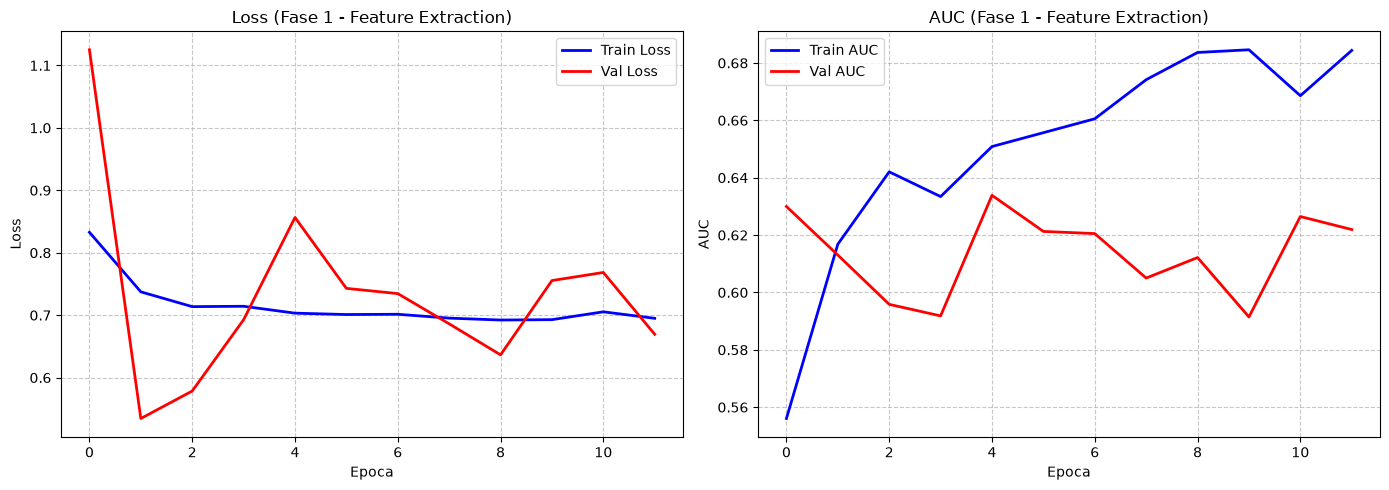

Grafico salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/experiments/exp_trad_aug_resnet50/figures/training_history_fase2_resnet50.png


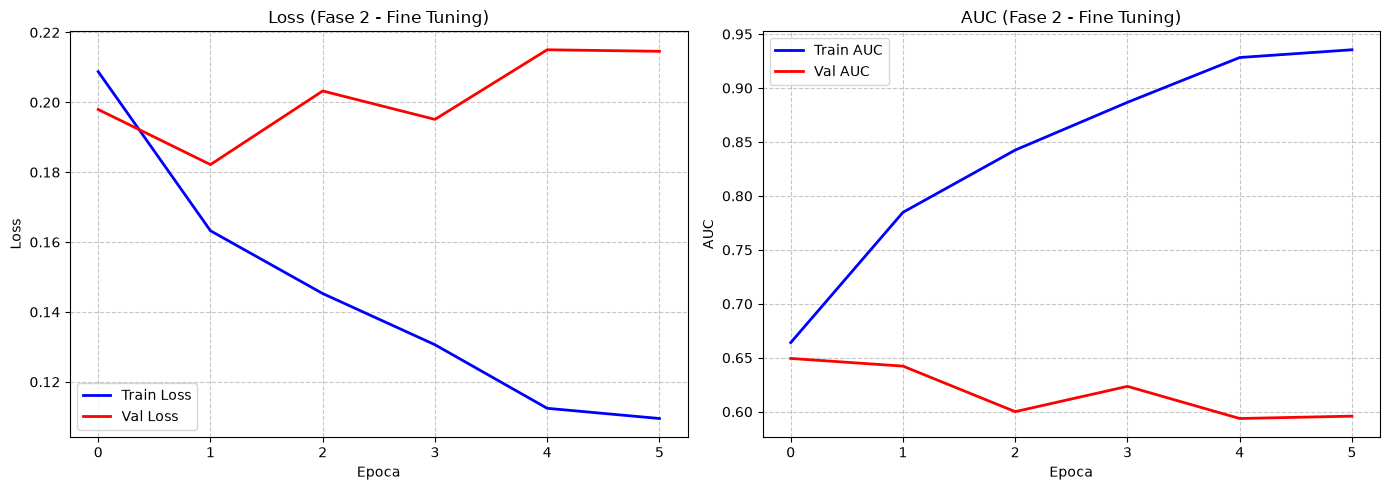

In [10]:
def plot_training_history(history, title_suffix="", save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_title('Loss ' + title_suffix); ax1.set_xlabel('Epoca'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.7)
    ax2.plot(history.history['auc'], label='Train AUC', color='blue', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red', linewidth=2)
    ax2.set_title('AUC ' + title_suffix); ax2.set_xlabel('Epoca'); ax2.set_ylabel('AUC')
    ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print("Grafico salvato in:", save_path)
    plt.show()

plot_training_history(history_phase1, "(Fase 1 - Feature Extraction)",
                      os.path.join(FIGURES_DIR, 'training_history_fase1_resnet50.png'))
plot_training_history(history_phase2, "(Fase 2 - Fine Tuning)",
                      os.path.join(FIGURES_DIR, 'training_history_fase2_resnet50.png'))

#### Valutazione sul test set
La soglia di Youden viene scelta sul validation set e applicata al test set per evitare un bias ottimistico

In [ ]:
#carica il miglior modello addestrato in fase 2 (solo inferenza -> compile=False, niente custom_objects)
best_model = keras.models.load_model(os.path.join(OUTPUT_DIR, 'trad_aug_resnet50_final_best.keras'), compile=False)

def predici(ds):
    yt, yp = [], []
    for imgs, labels in ds:
        yp.extend(best_model.predict(imgs, verbose=0).flatten())
        yt.extend(labels.numpy())
    return np.array(yt), np.array(yp)

#soglia di Youden calcolata dal validation set
val_true, val_prob = predici(val_ds)
fpr_v, tpr_v, thr_v = roc_curve(val_true, val_prob)
best_threshold = float(thr_v[np.argmax(tpr_v - fpr_v)])
print("soglia di Youden (VAL):", round(best_threshold, 4))

#inferenza sul test set + applica la soglia del validation set
test_true, test_prob = predici(test_ds)
test_pred = (test_prob >= best_threshold).astype(int)

#metriche sul test set
auc = roc_auc_score(test_true, test_prob)
report = classification_report(test_true, test_pred, target_names=['Sano', 'Malato'])
print("AUC (test):", round(float(auc), 4))
print(report)

metrics_dict = {
    'arch': ARCH, 'config': CONFIG, 'split': 'test',
    'threshold_youden_from_val': round(best_threshold, 4),
    'roc_auc': round(float(auc), 4),
    'accuracy': round(float(accuracy_score(test_true, test_pred)), 4),
    'precision_malato': round(float(precision_score(test_true, test_pred, pos_label=1, zero_division=0)), 4),
    'recall_malato': round(float(recall_score(test_true, test_pred, pos_label=1, zero_division=0)), 4),
    'f1_malato': round(float(f1_score(test_true, test_pred, pos_label=1, zero_division=0)), 4),
    'classification_report': report,
}
with open(os.path.join(OUTPUT_DIR, 'test_metrics_resnet50.json'), 'w') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
print("metriche salvate in test_metrics_resnet50.json")

#plot confusion matrix + ROC (test)
cm = confusion_matrix(test_true, test_pred)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(cm, cmap='Blues')
ax[0].set_xticks([0, 1]); ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Sano', 'Malato']); ax[0].set_yticklabels(['Sano', 'Malato'])
ax[0].set_xlabel('Predetto'); ax[0].set_ylabel('Reale'); ax[0].set_title('Confusion Matrix (test)')
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')
fpr_t, tpr_t, _ = roc_curve(test_true, test_prob)
ax[1].plot(fpr_t, tpr_t, lw=2, label='AUC = %.4f' % auc)
ax[1].plot([0, 1], [0, 1], '--', color='gray')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].set_title('ROC (test)'); ax[1].legend()
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'test_confusion_roc_resnet50.png'), dpi=150, bbox_inches='tight')
plt.show()

#### Valutazione con bootstrap

Il test set è sbilanciato (365 sani / 73 malati) per tanto si tengono tutti i postivi, campionando lo stesso numero di negativi. 

Le metriche vengono calcolate su N round e viene effettuata la media per evitare un Accuracy falsata dallo sbilanciamento.

Accuracy   0.4863 +/- 0.0256
Precision  0.4826 +/- 0.0355
Recall     0.3288 +/- 0.0000
F1         0.3906 +/- 0.0118
ROC_AUC    0.5010 +/- 0.0292


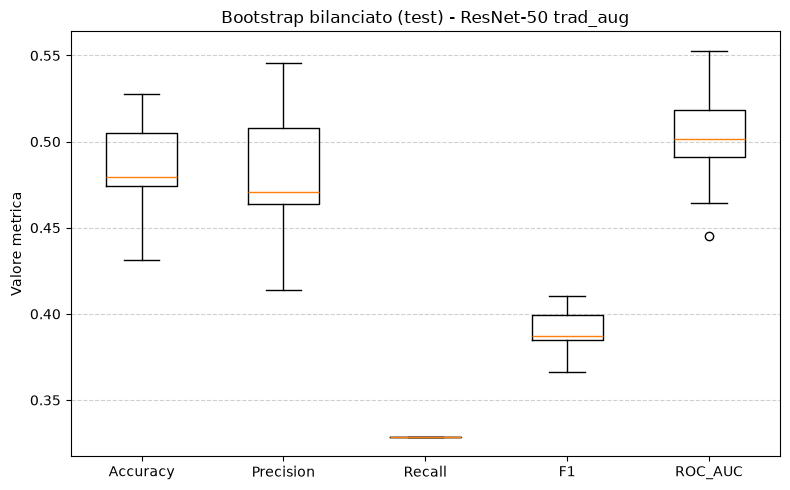

In [12]:
def bootstrap_bilanciato(y_true, y_prob, threshold, n_rounds=10, seed=SEED):
    rng = np.random.default_rng(seed)
    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n = min(len(pos_idx), len(neg_idx))
    out = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': [], 'ROC_AUC': []}
    for _ in range(n_rounds):
        sel_neg = rng.choice(neg_idx, size=n, replace=False)
        idx = np.concatenate([pos_idx, sel_neg])
        yt, yp = y_true[idx], y_prob[idx]
        pred = (yp >= threshold).astype(int)
        out['Accuracy'].append(accuracy_score(yt, pred))
        out['Precision'].append(precision_score(yt, pred, pos_label=1, zero_division=0))
        out['Recall'].append(recall_score(yt, pred, pos_label=1, zero_division=0))
        out['F1'].append(f1_score(yt, pred, pos_label=1, zero_division=0))
        out['ROC_AUC'].append(roc_auc_score(yt, yp))
    for k, v in out.items():
        print("%-10s %.4f +/- %.4f" % (k, np.mean(v), np.std(v)))
    return out

boot = bootstrap_bilanciato(test_true, test_prob, best_threshold, n_rounds=10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(list(boot.values()))
ax.set_xticklabels(list(boot.keys()))
ax.set_title('Bootstrap bilanciato (test) - ResNet-50 trad_aug')
ax.set_ylabel('Valore metrica'); ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'bootstrap_resnet50.png'), dpi=150, bbox_inches='tight')
plt.show()

#### Salvataggio del modello addestrato

In [ ]:
import shutil

MODEL_PATH = os.path.join(OUTPUT_DIR, 'trad_aug_resnet50_final_best.keras')
assert os.path.isfile(MODEL_PATH), f"modello non trovato: {MODEL_PATH}"
print("modello finale:", MODEL_PATH, "(%.1f MB)" % (os.path.getsize(MODEL_PATH) / (1024 ** 2)))

DRIVE_DIR = None 
if DRIVE_DIR:
    os.makedirs(DRIVE_DIR, exist_ok=True)
    print("copiato su drive", shutil.copy2(MODEL_PATH, DRIVE_DIR))
elif str(BASE_PATH).startswith('/content/drive'):
    print("Colab: BASE_PATH e' su Drive -> il modello e' GIA' nel tuo Drive (in experiments/).")
    print("Condividilo e copia l'ID del file nel notebook 10 (TRAD_AUG_MODEL_DRIVE_ID).")
else:
    print("WSL: il file e' locale. Caricalo a mano nella cartella Drive del team:")
    print("  https://drive.google.com/drive/folders/1m2cEDgXQ2KxzSErXnEC-eeSNN4iPF_Un")
    print("poi metti l'ID del file in 10_Valutazione_Sostenibilita (TRAD_AUG_MODEL_DRIVE_ID).")